<a href="https://colab.research.google.com/github/HussainDiyab/Hussain_Diyab/blob/main/EDA_Phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis - Breast Cancer Wisconsin Dataset

**EDA Course Project, Phase 1 and 2**

**Hussain Diyab**

### About the dataset

The data comes from digitised images of breast mass samples taken by fine needle aspiration.
For each image, ten features of the cell nuclei were measured:

radius, texture, perimeter, area, smoothness, compactness, concavity, concave points,
symmetry and fractal dimension.

Each of these ten is recorded three times, giving 30 columns in total:

* `_mean` is the average value across all nuclei in the image
* `_se` is the standard error
* `_worst` is the average of the three largest values

The column we want to explain is `diagnosis`, where M means malignant and B means benign.

### What this notebook covers

1. Loading the dataset
2. Basic statistical analysis
3. Handling missing data
4. Data cleaning
5. Data transformation
6. Univariate analysis (3 plots)
7. Bivariate analysis (3 plots)
8. Multivariate analysis (3 plots)
9. Conclusion

Phase 2

10. 1D statistical analysis
11. 2D statistical analysis
12. 3D statistical analysis
13. K-means clustering
14. Hierarchical clustering
15. Phase 2 conclusion

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

# plot settings used for the whole notebook
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# same two colours for the two classes everywhere
colors = {"B": "steelblue", "M": "coral"}

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 150)

## 1. Loading the dataset

The file is read straight from its raw GitHub link so the notebook runs in Colab without
uploading anything.

In [2]:
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/bcancer.csv"
df = pd.read_csv(url)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 569
Columns: 33


In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

The dataset has 569 rows. Along with the 30 measurements there is an `id` column and a column
called `Unnamed: 32`, which appears because the header row in the CSV ends with an extra comma.
Both are dealt with below.

## 2. Basic statistical analysis

In [5]:
# summary statistics for the numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [6]:
# how many of each diagnosis
counts = df["diagnosis"].value_counts()
print(counts)
print()
print(df["diagnosis"].value_counts(normalize=True).round(3) * 100)

diagnosis
B    357
M    212
Name: count, dtype: int64

diagnosis
B    62.7
M    37.3
Name: proportion, dtype: float64


In [7]:
# average value of each mean feature for the two classes
mean_cols = [c for c in df.columns if c.endswith("_mean")]

compare = df.groupby("diagnosis")[mean_cols].mean().T
compare["difference"] = compare["M"] - compare["B"]
compare.round(3)

diagnosis,B,M,difference
radius_mean,12.147,17.463,5.316
texture_mean,17.915,21.605,3.690
perimeter_mean,78.075,115.365,37.290
area_mean,462.790,978.376,515.586
smoothness_mean,0.092,0.103,0.010
compactness_mean,0.080,0.145,0.065
concavity_mean,0.046,0.161,0.115
concave points_mean,0.026,0.088,0.062
symmetry_mean,0.174,0.193,0.019
fractal_dimension_mean,0.063,0.063,-0.000


There are 357 benign and 212 malignant cases, so roughly 63% against 37%. The classes are not
balanced but neither is very small.

Every mean feature is higher for malignant cases. The gap is largest for concavity, concave
points and compactness, and smallest for fractal dimension.

## 3. Handling missing data

In [8]:
# count missing values per column
missing = df.isnull().sum()
print("Total missing values:", missing.sum())
print()
print(missing[missing > 0])

Total missing values: 569

Unnamed: 32    569
dtype: int64


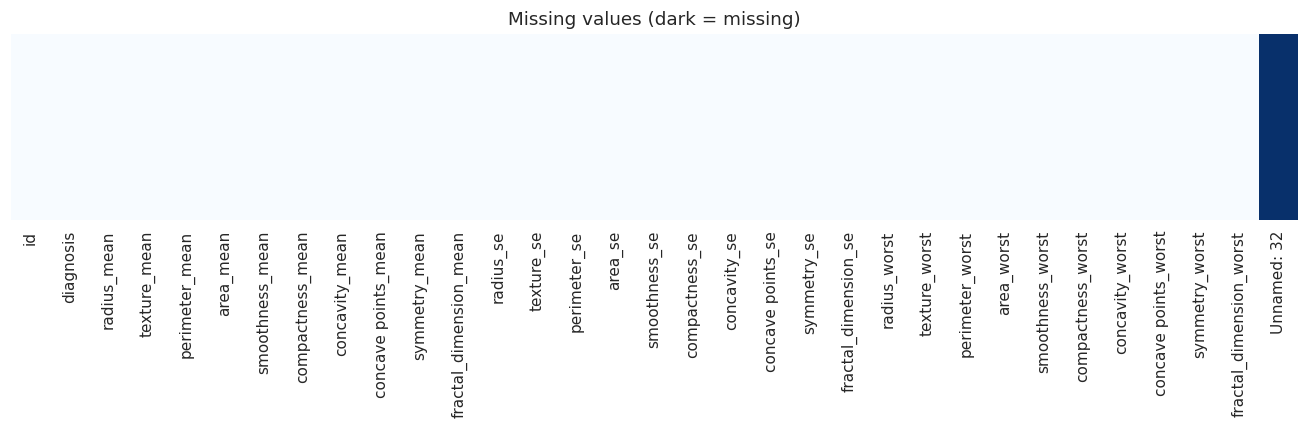

In [9]:
# visual check of where the missing values are
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="Blues")
plt.title("Missing values (dark = missing)")
plt.tight_layout()
plt.show()

All the missing values sit in one column, `Unnamed: 32`, which is empty for every row. It is not
real data, it is just an artefact of the extra comma in the header. Since the column has no values
at all it cannot be filled in, so it is dropped.

Apart from that column there are no missing values anywhere in the dataset.

In [10]:
# drop the empty column
df = df.drop(columns=["Unnamed: 32"])

print("Shape after dropping:", df.shape)
print("Missing values left:", df.isnull().sum().sum())

Shape after dropping: (569, 32)
Missing values left: 0


If there had been missing values in a real feature, the usual approach would be to fill them with
the median, since most of these columns are skewed and the median is not affected by extreme
values. The code for that would be:

```python
df["radius_mean"] = df["radius_mean"].fillna(df["radius_mean"].median())
```

It is not needed here because nothing is missing.

## 4. Data cleaning

In [11]:
# id is just a record number, it is not useful for analysis
print("Unique ids:", df["id"].nunique(), "out of", len(df), "rows")

df = df.drop(columns=["id"])
print("Shape:", df.shape)

Unique ids: 569 out of 569 rows
Shape: (569, 31)


In [12]:
# check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [13]:
# check the target column has only the two expected values
print("Values in diagnosis:", df["diagnosis"].unique())

# check no measurement is negative, since all of them are sizes or ratios
print("Columns with negative values:",
      (df.select_dtypes("number") < 0).any().sum())

Values in diagnosis: ['M' 'B']
Columns with negative values: 0


In [14]:
# look for outliers using the IQR rule
features = df.drop(columns=["diagnosis"])

Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)
IQR = Q3 - Q1

outliers = (features < Q1 - 1.5 * IQR) | (features > Q3 + 1.5 * IQR)

print("Rows with at least one outlier:", outliers.any(axis=1).sum(), "out of", len(df))
print()
print("Features with the most outliers:")
print(outliers.sum().sort_values(ascending=False).head(8))

Rows with at least one outlier: 171 out of 569

Features with the most outliers:
area_se                 65
radius_se               38
perimeter_se            38
area_worst              35
smoothness_se           30
fractal_dimension_se    28
compactness_se          28
symmetry_se             27
dtype: int64


In [15]:
# check which class the outliers belong to
by_class = pd.DataFrame({
    "outlier values": outliers.sum(axis=1).groupby(df["diagnosis"]).sum(),
    "rows": df["diagnosis"].value_counts(),
})
by_class["per row"] = (by_class["outlier values"] / by_class["rows"]).round(2)
by_class

,outlier values,rows,per row
diagnosis,,,
B,139,357,0.39
M,469,212,2.21


171 rows out of 569 contain at least one outlier by the IQR rule, and they are not spread evenly.
Malignant rows have about 2.2 outlier values each while benign rows have about 0.4, so the
outliers are concentrated in the malignant group.

This means they are not mistakes in the data. Malignant tumours really do have larger and more
irregular nuclei, so the IQR rule flags them simply because the data contains two different
groups mixed together. Removing them would throw away the cases the analysis is meant to find,
so they are kept.

Summary of cleaning: dropped `Unnamed: 32` (empty), dropped `id` (not a feature), no duplicates
found, no missing values, no outliers removed.

## 5. Data transformation

In [16]:
# convert the diagnosis into numbers so it can be used in correlations
df["target"] = df["diagnosis"].map({"B": 0, "M": 1})

df[["diagnosis", "target"]].head()

,diagnosis,target
0,M,1
1,M,1
2,M,1
3,M,1
4,M,1


In [17]:
# check how skewed the features are
feature_cols = [c for c in df.columns if c not in ["diagnosis", "target"]]

skew_before = df[feature_cols].skew()
print("Features with skew above 0.75:", (skew_before > 0.75).sum(), "out of", len(feature_cols))
print()
print(skew_before.sort_values(ascending=False).head(6).round(2))

Features with skew above 0.75: 24 out of 30

area_se                 5.45
concavity_se            5.11
fractal_dimension_se    3.92
perimeter_se            3.44
radius_se               3.09
smoothness_se           2.31
dtype: float64


In [18]:
# apply a log transform to reduce the skew
# log1p is used instead of log because some columns contain zeros
skewed = skew_before[skew_before > 0.75].index

df_log = df.copy()
df_log[skewed] = np.log1p(df_log[skewed])

result = pd.DataFrame({
    "before": skew_before,
    "after": df_log[feature_cols].skew(),
}).round(2)

result.sort_values("before", ascending=False).head(8)

,before,after
area_se,5.45,0.85
concavity_se,5.11,4.23
fractal_dimension_se,3.92,3.87
perimeter_se,3.44,1.03
radius_se,3.09,1.71
smoothness_se,2.31,2.28
symmetry_se,2.20,2.14
compactness_se,1.90,1.82


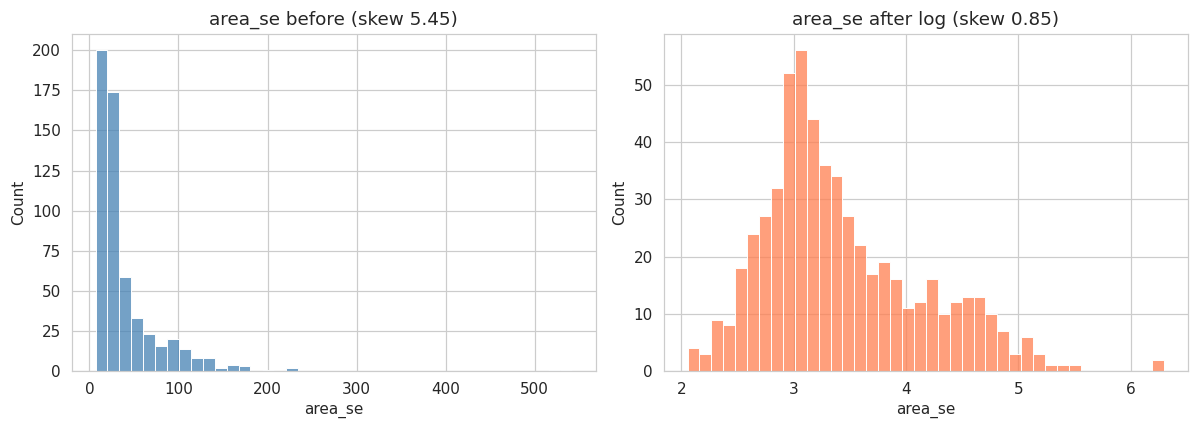

In [19]:
# show the effect of the log transform on one column
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(df["area_se"], bins=40, color="steelblue", ax=axes[0])
axes[0].set_title("area_se before (skew %.2f)" % df["area_se"].skew())

sns.histplot(df_log["area_se"], bins=40, color="coral", ax=axes[1])
axes[1].set_title("area_se after log (skew %.2f)" % df_log["area_se"].skew())

plt.tight_layout()
plt.show()

In [20]:
# scale the features so they are all on the same range
# this is needed for PCA later, since area_mean is around 650 while
# fractal_dimension_mean is around 0.06
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[feature_cols]), columns=feature_cols)

print("Before scaling:")
print(df[["area_mean", "fractal_dimension_mean"]].mean().round(3))
print()
print("After scaling:")
print(df_scaled[["area_mean", "fractal_dimension_mean"]].mean().round(3))

Before scaling:
area_mean                 654.889
fractal_dimension_mean      0.063
dtype: float64

After scaling:
area_mean                -0.0
fractal_dimension_mean    0.0
dtype: float64


In [21]:
# split radius_mean into four size groups
df["radius_group"] = pd.qcut(df["radius_mean"], 4,
                             labels=["Small", "Medium", "Large", "Very large"])

table = pd.crosstab(df["radius_group"], df["diagnosis"])
table["% malignant"] = (table["M"] / (table["M"] + table["B"]) * 100).round(1)
table

diagnosis,B,M,% malignant
radius_group,,,
Small,140,3,2.1
Medium,128,14,9.9
Large,83,59,41.5
Very large,6,136,95.8


24 of the 30 features have a skew above 0.75, so a log transform was applied to those. It works
well on columns like `area_se`, where the skew drops from 5.45 to 0.85. It does not help much on
`concavity_se` or `smoothness_se`, because their skew comes from a group of zeros at the bottom
rather than a long tail at the top, and log1p leaves zeros unchanged.

Splitting radius into four groups shows the pattern clearly: 2.1% of the smallest tumours are
malignant, rising to 9.9%, then 41.5%, then 95.8% in the largest group.

## 6. Univariate analysis

Looking at one variable at a time.

### Plot 1: How many of each diagnosis

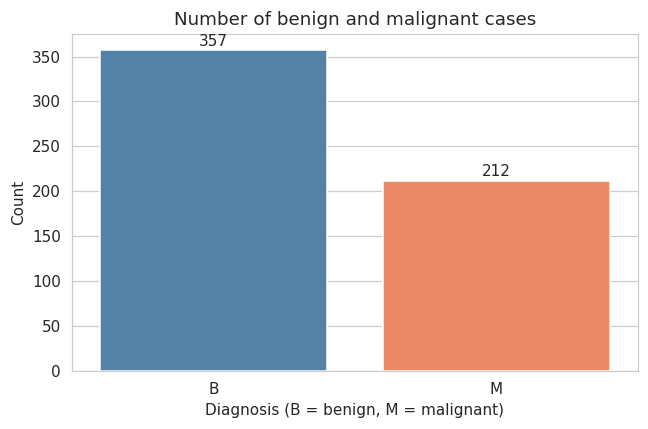

In [22]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="diagnosis", order=["B", "M"], palette=colors)

# write the count on top of each bar
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width() / 2, p.get_height() + 5),
                ha="center")

plt.title("Number of benign and malignant cases")
plt.xlabel("Diagnosis (B = benign, M = malignant)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

357 benign against 212 malignant. Since 63% of the data is benign, a model that always predicted
benign would already be right 63% of the time, so accuracy alone would not be a fair way to judge
one.

### Plot 2: Distribution of the main measurements

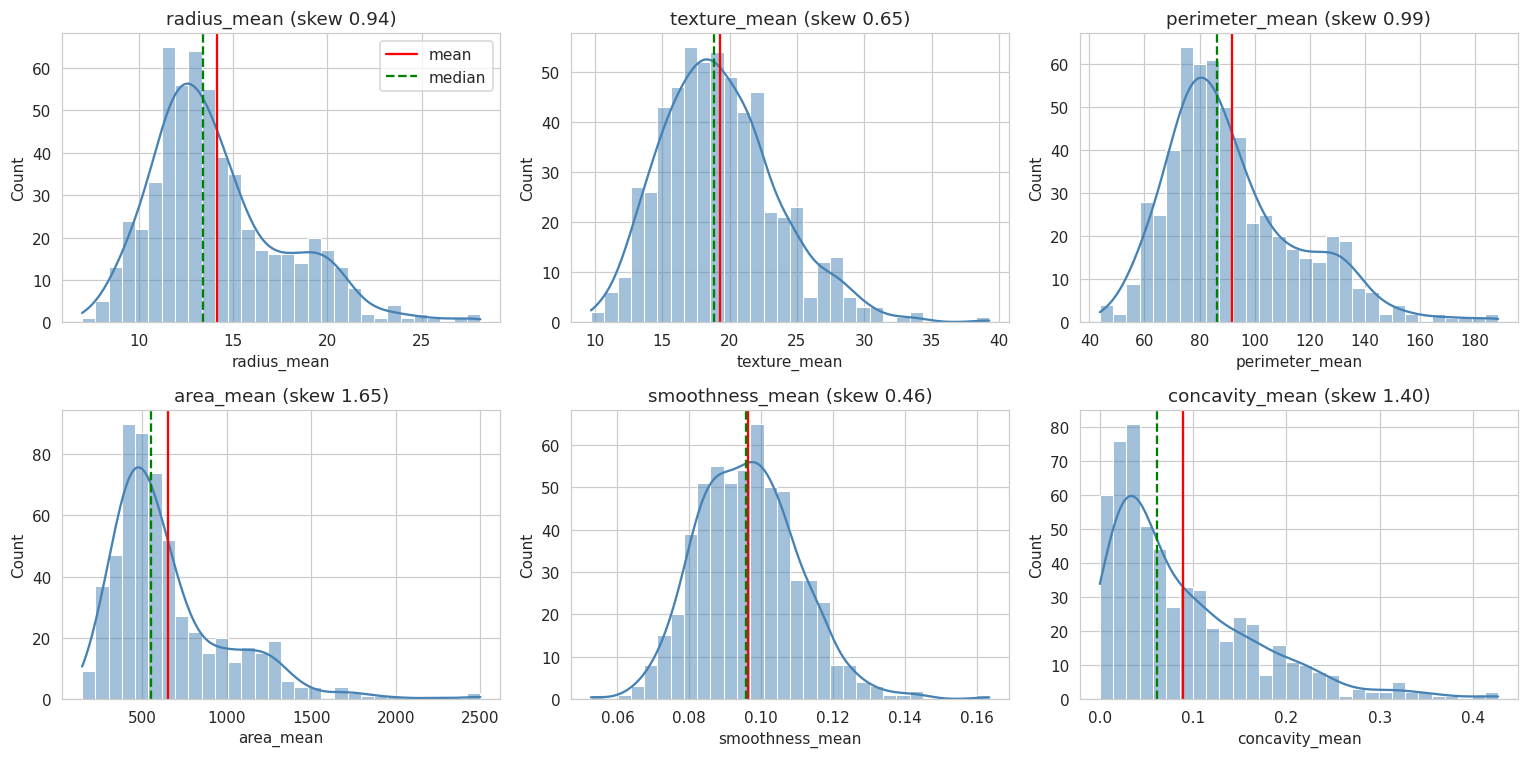

In [23]:
show = ["radius_mean", "texture_mean", "perimeter_mean",
        "area_mean", "smoothness_mean", "concavity_mean"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, col in zip(axes.flat, show):
    sns.histplot(df[col], bins=30, kde=True, color="steelblue", ax=ax)
    ax.axvline(df[col].mean(), color="red", label="mean")
    ax.axvline(df[col].median(), color="green", linestyle="--", label="median")
    ax.set_title("%s (skew %.2f)" % (col, df[col].skew()))
    ax.set_ylabel("Count")

axes.flat[0].legend()
plt.tight_layout()
plt.show()

Most of these are skewed to the right, which is why the mean line sits to the right of the median
line in nearly every plot. `area_mean` is the most skewed. `smoothness_mean` is the closest to a
normal shape.

`concavity_mean` has a second smaller bump on the right rather than one clean peak. That is the
malignant group starting to separate out, which is confirmed in section 7.

### Plot 3: Spread of the ten mean features

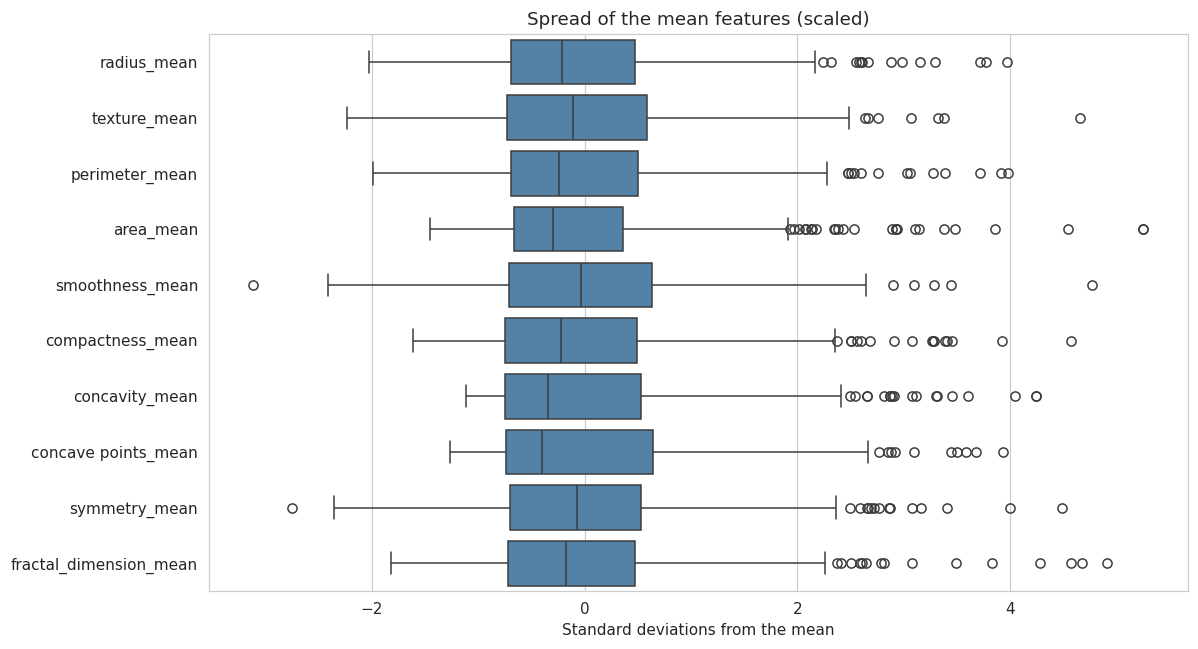

In [24]:
# the features are scaled first so they can share one axis
plt.figure(figsize=(11, 6))
sns.boxplot(data=df_scaled[mean_cols], orient="h", color="steelblue")

plt.title("Spread of the mean features (scaled)")
plt.xlabel("Standard deviations from the mean")
plt.tight_layout()
plt.show()

Every feature has points falling outside the whiskers, and in each case they are on the right hand
side, meaning unusually high values rather than low ones. `area_mean` and `concavity_mean` have
the longest tails.

The fact that the outliers are only on one side is the important part. Random errors would appear
on both sides. Here they are all high values, which fits with them coming from the malignant
group.

## 7. Bivariate analysis

Looking at two variables together, mainly each feature against the diagnosis.

### Plot 1: Key measurements split by diagnosis

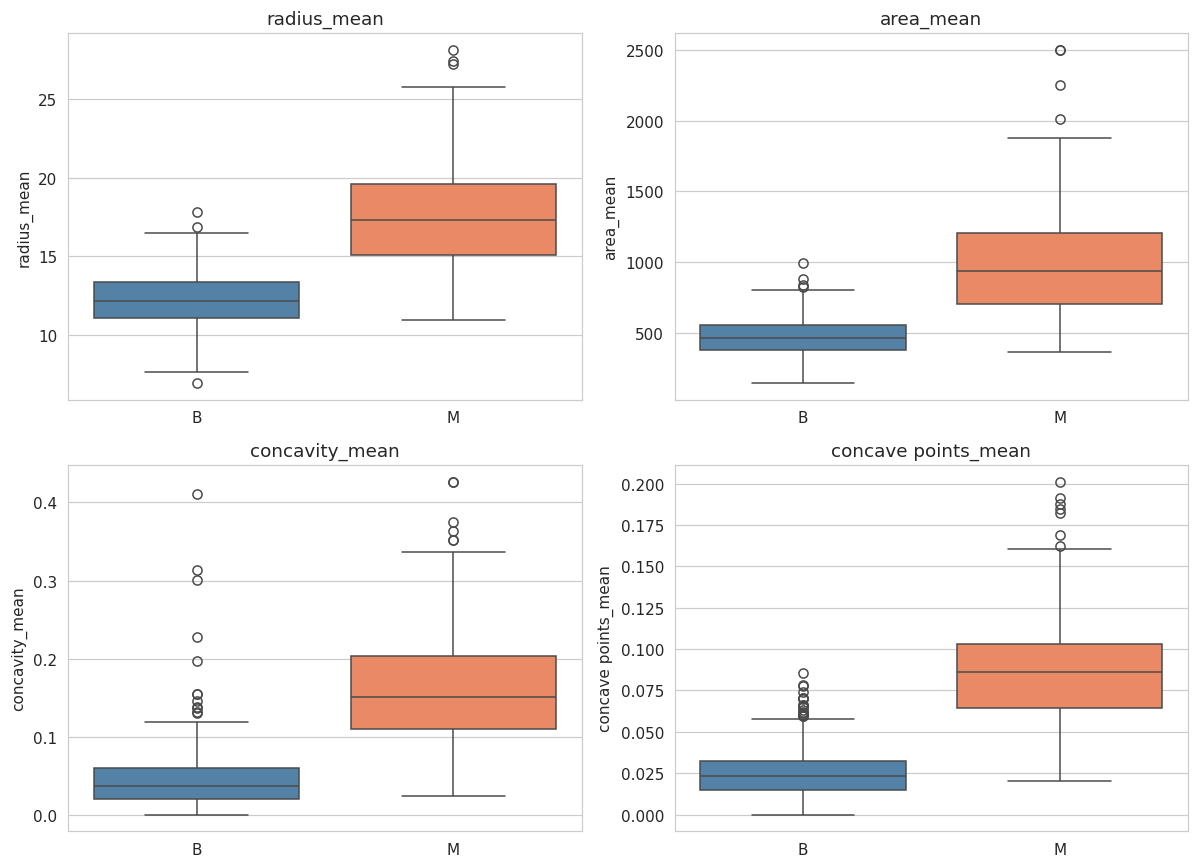

In [25]:
selected = ["radius_mean", "area_mean", "concavity_mean", "concave points_mean"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, col in zip(axes.flat, selected):
    sns.boxplot(data=df, x="diagnosis", y=col, order=["B", "M"],
                palette=colors, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

All four are clearly higher for malignant cases. `concave points_mean` separates the two groups
best, since the two boxes hardly overlap at all. `radius_mean` and `area_mean` separate them well
but there is more overlap in the middle.

The malignant boxes are also taller, so malignant tumours vary more between cases than benign ones
do.

### Plot 2: Two features plotted against each other

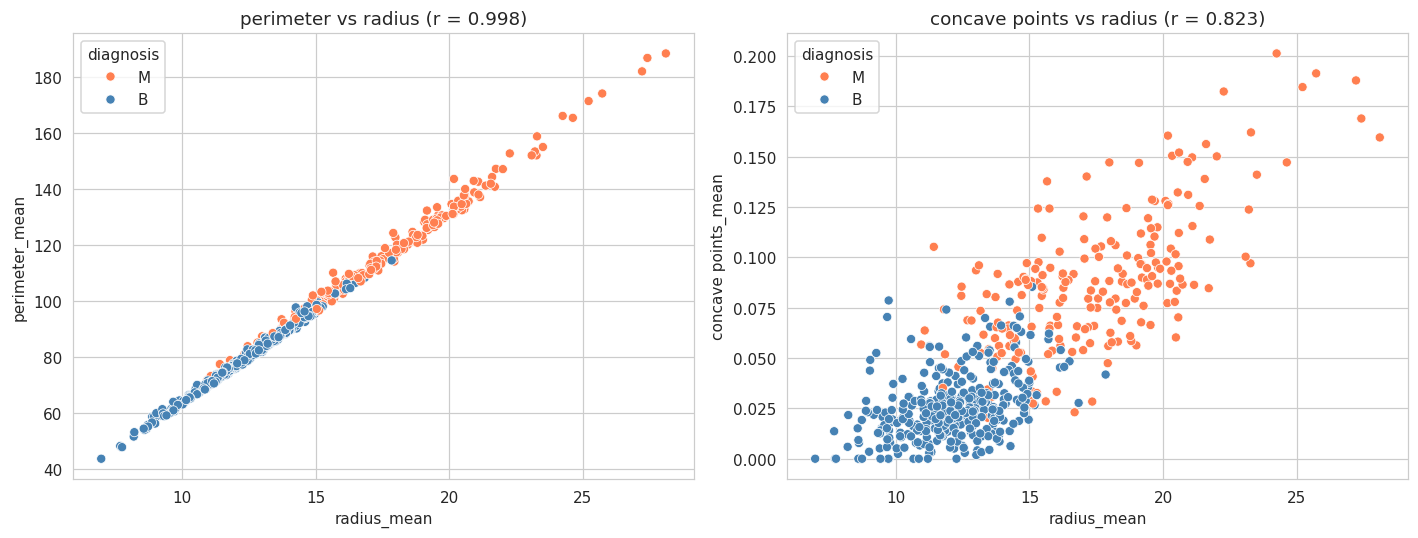

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x="radius_mean", y="perimeter_mean",
                hue="diagnosis", palette=colors, ax=axes[0])
axes[0].set_title("perimeter vs radius (r = %.3f)"
                  % df["radius_mean"].corr(df["perimeter_mean"]))

sns.scatterplot(data=df, x="radius_mean", y="concave points_mean",
                hue="diagnosis", palette=colors, ax=axes[1])
axes[1].set_title("concave points vs radius (r = %.3f)"
                  % df["radius_mean"].corr(df["concave points_mean"]))

plt.tight_layout()
plt.show()

The two plots show different things.

On the left, perimeter and radius line up almost perfectly, with a correlation of 0.998. That is
not a finding about tumours, it is just geometry, since the perimeter of a circle is 2 x pi x r.
The two columns are carrying the same information.

On the right, the two classes sit in different parts of the plot. Benign cases are grouped in the
bottom left and malignant cases spread up and to the right, with only a small overlap between
them.

### Plot 3: Correlation of each feature with the diagnosis

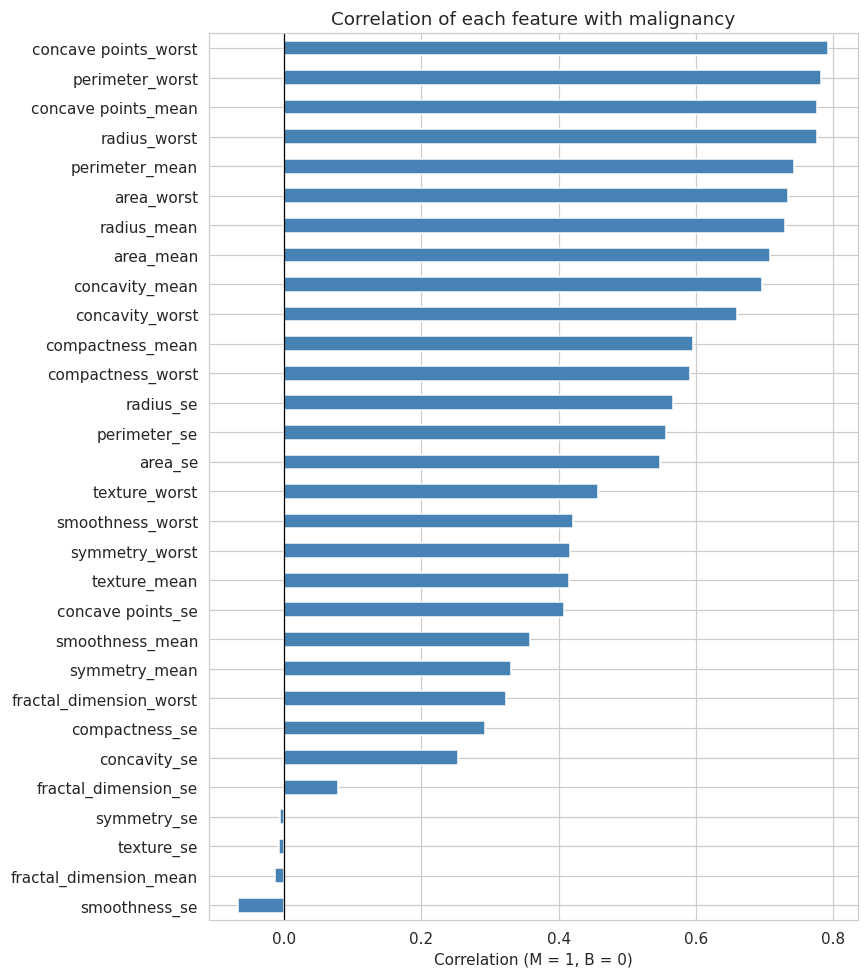

In [27]:
target_corr = df[feature_cols].corrwith(df["target"]).sort_values()

plt.figure(figsize=(8, 9))
target_corr.plot(kind="barh", color="steelblue")

plt.title("Correlation of each feature with malignancy")
plt.xlabel("Correlation (M = 1, B = 0)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

In [28]:
print("Strongest features:")
print(target_corr.abs().sort_values(ascending=False).head(8).round(3))

Strongest features:
concave points_worst    0.794
perimeter_worst         0.783
concave points_mean     0.777
radius_worst            0.776
perimeter_mean          0.743
area_worst              0.734
radius_mean             0.730
area_mean               0.709
dtype: float64


The strongest four are `concave points_worst` (0.794), `perimeter_worst` (0.783),
`concave points_mean` (0.777) and `radius_worst` (0.776).

Two things stand out. First, the `_worst` version of a measurement is usually a better indicator
than the `_mean` version, which is true for 8 of the 10 measurements. This makes sense, because a
tumour is judged by its most abnormal cells rather than its average ones.

Second, only four features have a negative correlation and all four are close to zero, the largest
being `smoothness_se` at -0.067. So almost every measurement in this dataset increases when the
tumour is malignant.

## 8. Multivariate analysis

Looking at many variables at the same time.

### Plot 1: Correlation between all the features

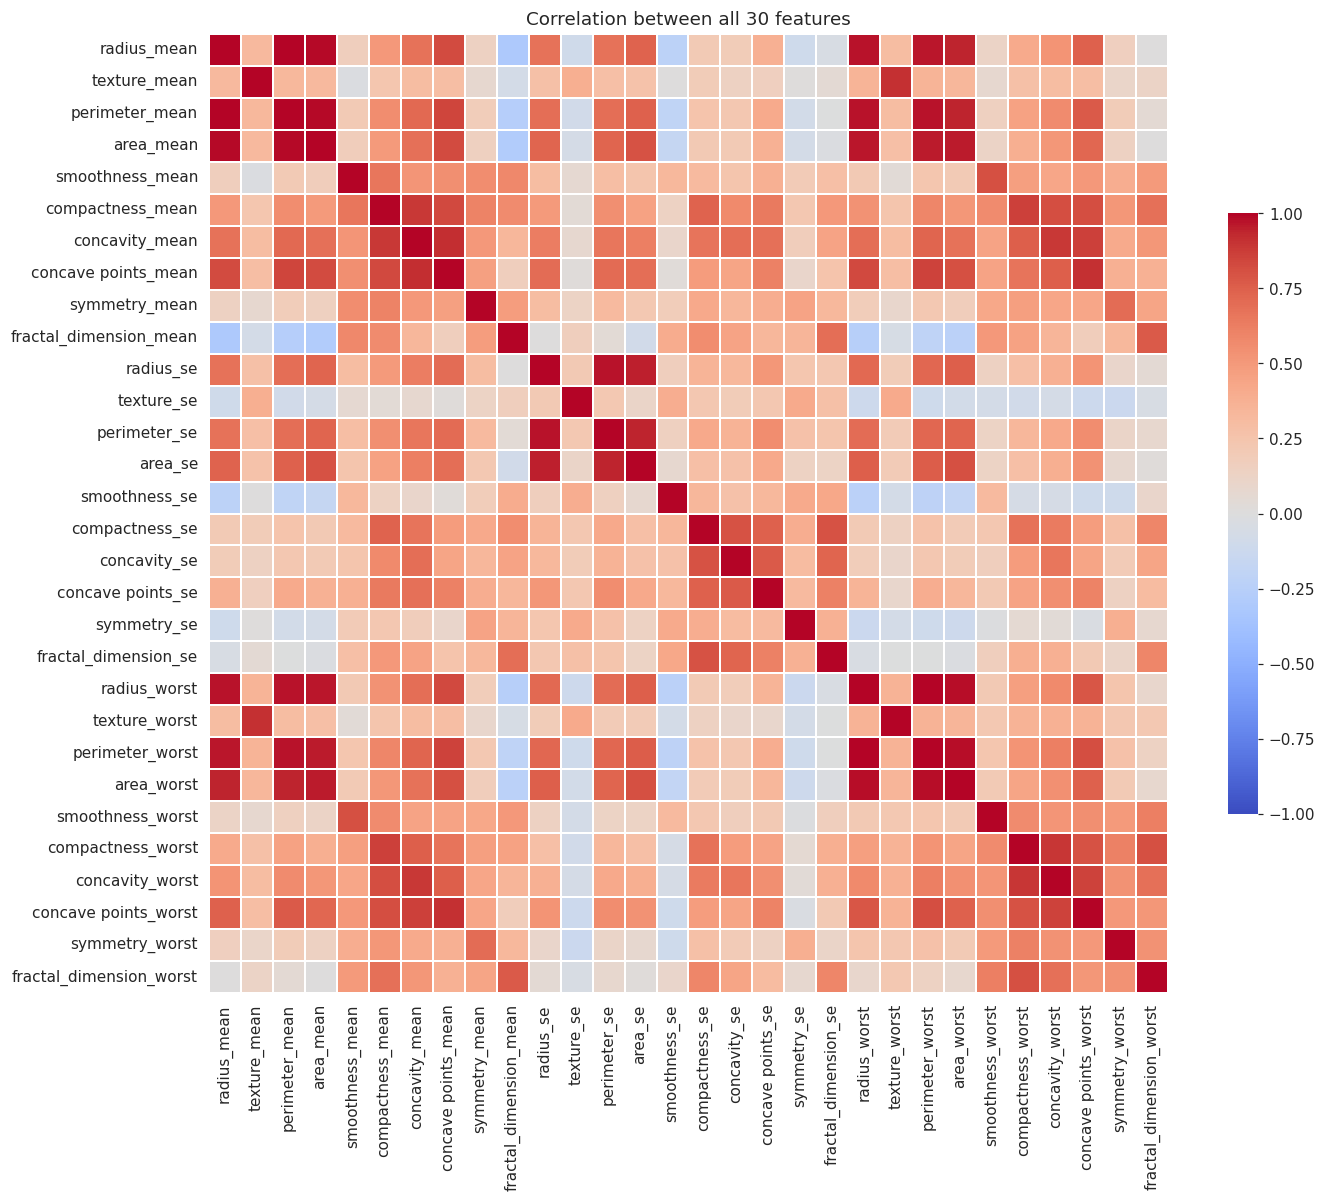

In [29]:
corr = df[feature_cols].corr()

plt.figure(figsize=(13, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.3, cbar_kws={"shrink": 0.6})

plt.title("Correlation between all 30 features")
plt.tight_layout()
plt.show()

In [30]:
# list the most correlated pairs
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
pairs = pairs.sort_values(ascending=False)

print("Most correlated pairs:")
print(pairs.head(8).round(3))
print()
print("Pairs correlated above 0.90:", (pairs > 0.90).sum())

Most correlated pairs:
radius_mean      perimeter_mean     0.998
radius_worst     perimeter_worst    0.994
radius_mean      area_mean          0.987
perimeter_mean   area_mean          0.987
radius_worst     area_worst         0.984
perimeter_worst  area_worst         0.978
radius_se        perimeter_se       0.973
perimeter_mean   perimeter_worst    0.970
dtype: float64

Pairs correlated above 0.90: 21


The heatmap has clear dark red blocks rather than being evenly mixed. Radius, perimeter and area
correlate above 0.97 with each other in all three of their versions, because all three are
measuring the size of the same nucleus. A second block joins compactness, concavity and concave
points, which all describe how irregular the shape is.

Texture, smoothness and symmetry are much less related to everything else, so they carry
information the size columns do not.

In total 21 pairs of features correlate above 0.90. This means the 30 columns hold far less than
30 separate pieces of information, which is what PCA is used for below.

### Plot 2: Pair plot of the strongest features

Features used: ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean']


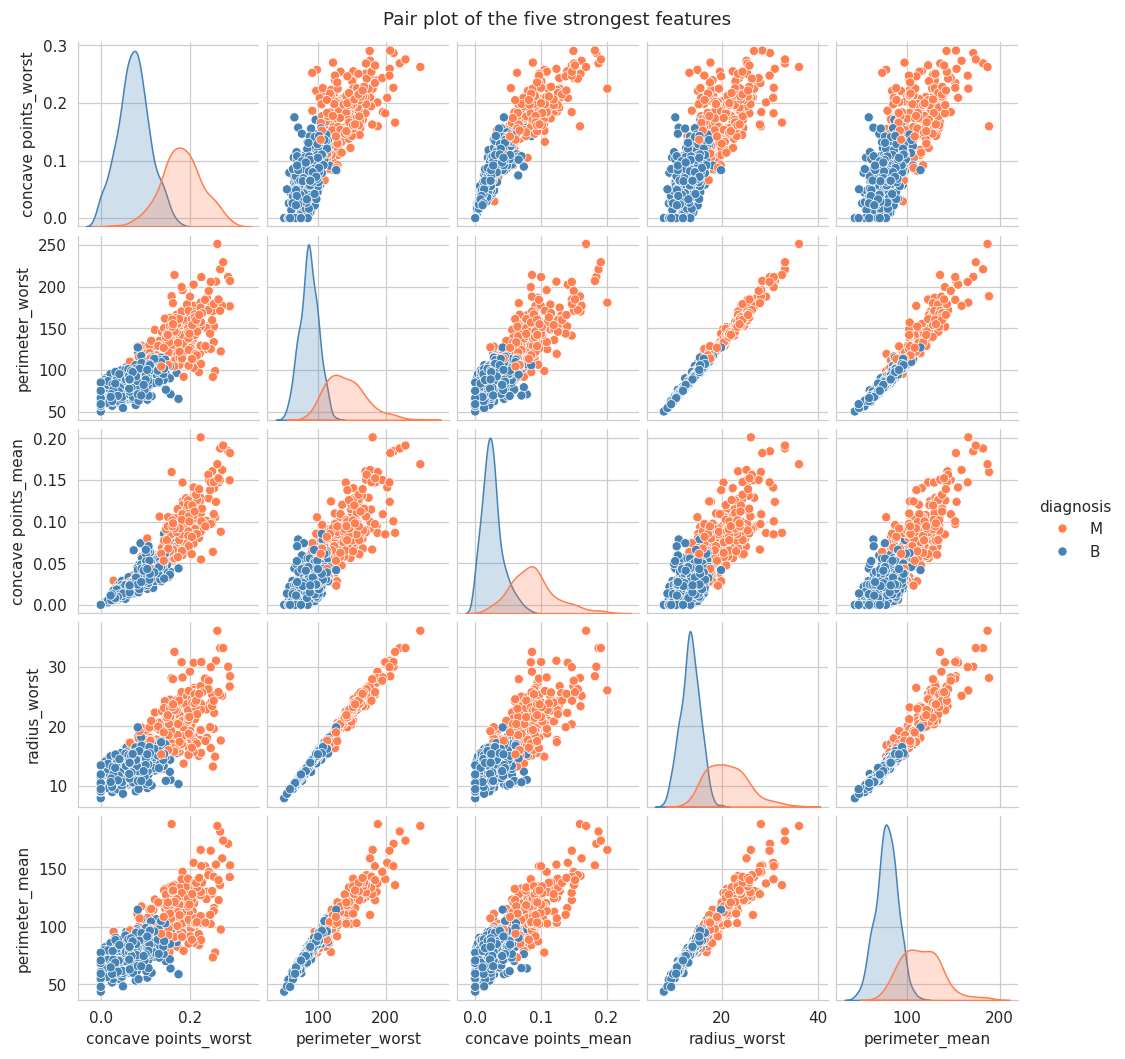

In [31]:
top5 = target_corr.abs().sort_values(ascending=False).head(5).index.tolist()
print("Features used:", top5)

sns.pairplot(df[top5 + ["diagnosis"]], hue="diagnosis", palette=colors,
             diag_kind="kde", height=1.9)

plt.suptitle("Pair plot of the five strongest features", y=1.01)
plt.show()

Along the diagonal, each feature shows two peaks, with benign on the left and malignant on the
right, but they overlap in the middle. So no single feature separates the two classes on its own.

In the scatter plots the two colours sit in different areas, and the separation is better using two
features together than either one alone. The redundancy shows up here as well, since
`perimeter_worst` against `radius_worst` forms a straight line while `concave points_worst` against
`radius_worst` forms a proper cloud.

### Plot 3: Principal component analysis

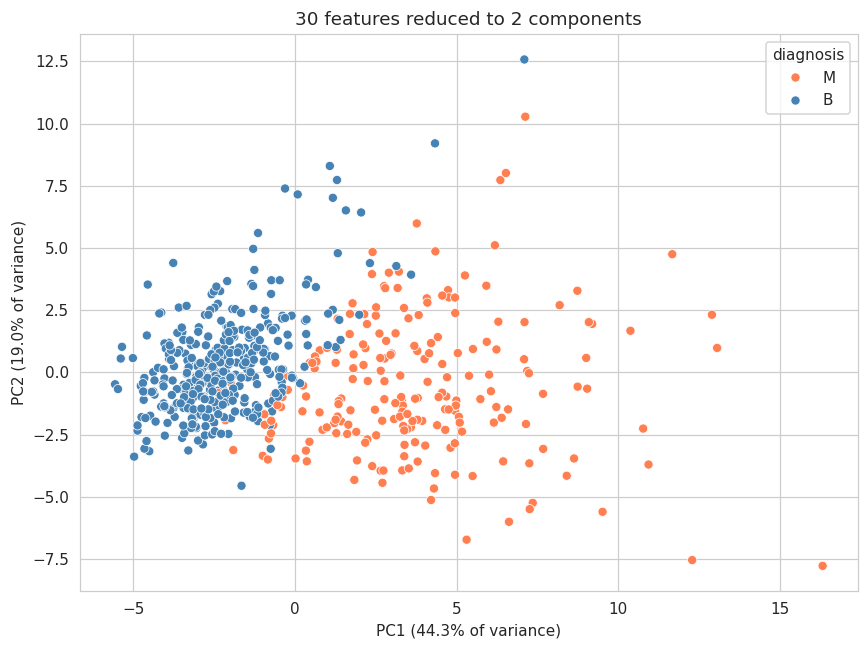

In [32]:
pca = PCA(n_components=2)
components = pca.fit_transform(df_scaled)

pca_df = pd.DataFrame(components, columns=["PC1", "PC2"])
pca_df["diagnosis"] = df["diagnosis"].values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="diagnosis", palette=colors)

plt.title("30 features reduced to 2 components")
plt.xlabel("PC1 (%.1f%% of variance)" % (pca.explained_variance_ratio_[0] * 100))
plt.ylabel("PC2 (%.1f%% of variance)" % (pca.explained_variance_ratio_[1] * 100))
plt.tight_layout()
plt.show()

In [33]:
# how many components are needed to keep most of the information
full = PCA().fit(df_scaled)
cumulative = np.cumsum(full.explained_variance_ratio_)

print("PC1 explains: %.1f%%" % (cumulative[0] * 100))
print("PC1 and PC2 together: %.1f%%" % (cumulative[1] * 100))
print("Components needed for 95%:", np.argmax(cumulative >= 0.95) + 1, "out of 30")

PC1 explains: 44.3%
PC1 and PC2 together: 63.2%
Components needed for 95%: 10 out of 30


PC1 alone explains 44.3% of the variation and the first two together explain 63.2%, so most of what
the 30 columns contain survives being reduced to 2. Only 10 components are needed to keep 95% of
the information, which confirms how much repetition there is between the features.

In the plot the two classes form two separate groups along PC1, with benign on the left and
malignant on the right, and only a narrow band where they mix. This is the clearest single picture
of the separation in the whole notebook.

## 9. Conclusion

**Data quality**

The dataset has 569 rows and no duplicates. The only column with missing values was
`Unnamed: 32`, which was empty throughout and came from an extra comma in the CSV header, so it
was dropped. `id` was also removed since it is only a record number. After that the data was
complete, with nothing left to fill in.

171 rows contain outliers by the IQR rule, but these were kept rather than removed, because they
are concentrated in the malignant group and represent real tumour measurements rather than errors.

24 of the 30 features were skewed to the right and were log transformed, and all the features were
scaled before PCA.

**What the analysis showed**

1. Almost every measurement increases when a tumour is malignant. 26 of the 30 features have a
   positive correlation with malignancy and the four negative ones are all below 0.07, which is
   effectively zero.

2. The shape of the nucleus matters more than its size. `concave points_worst` (0.794) and
   `concave points_mean` (0.777) are the two strongest individual indicators.

3. The `_worst` columns are usually better indicators than the `_mean` columns, which holds for 8
   of the 10 measurements. A tumour is judged by its most abnormal cells.

4. There is a lot of repetition between the features. Radius, perimeter and area correlate above
   0.97 with each other, and 21 pairs correlate above 0.90. PCA showed that 10 components hold 95%
   of the information from all 30 columns.

5. The two classes can be separated. On the first two principal components they form two distinct
   groups with only a small overlap.

6. Malignant cases vary far more than benign ones. In every box plot the malignant box is taller,
   so benign tumours are consistently small and regular while malignant ones differ a lot from case
   to case.

**Points for the next phase**

Because so many features repeat the same information, either some of them should be dropped or the
PCA components should be used instead. The `_worst` features look the most useful. Scaling will be
needed for any model that measures distance. Given that 63% of the cases are benign, accuracy on
its own would not show whether a model is actually working, so recall should be checked as well,
since missing a malignant case is the more serious mistake.

# Phase 2

Statistical analysis in one, two and three dimensions, followed by K-means and hierarchical
clustering.

In [34]:
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

## 10. 1D statistical analysis

Measures of central tendency, spread and shape for each of the ten mean features.

In [35]:
x = df[mean_cols]
stats_1d = pd.DataFrame({
    "mean": x.mean(),
    "median": x.median(),
    "mode": x.mode().iloc[0],
    "std": x.std(),
    "variance": x.var(),
    "min": x.min(),
    "max": x.max(),
    "range": x.max() - x.min(),
    "IQR": x.quantile(0.75) - x.quantile(0.25),
    "CV %": x.std() / x.mean() * 100,
    "skew": x.skew(),
    "kurtosis": x.kurt(),
})
stats_1d.round(3)

,mean,median,mode,std,variance,min,max,range,IQR,CV %,skew,kurtosis
radius_mean,14.127,13.370,12.340,3.524,12.419,6.981,28.110,21.129,4.080,24.945,0.942,0.846
texture_mean,19.290,18.840,14.930,4.301,18.499,9.710,39.280,29.570,5.630,22.297,0.650,0.758
perimeter_mean,91.969,86.240,82.610,24.299,590.440,43.790,188.500,144.710,28.930,26.421,0.991,0.972
area_mean,654.889,551.100,512.200,351.914,123843.554,143.500,2501.000,2357.500,362.400,53.736,1.646,3.652
smoothness_mean,0.096,0.096,0.101,0.014,0.000,0.053,0.163,0.111,0.019,14.595,0.456,0.856
compactness_mean,0.104,0.093,0.115,0.053,0.003,0.019,0.345,0.326,0.065,50.616,1.190,1.650
concavity_mean,0.089,0.062,0.000,0.080,0.006,0.000,0.427,0.427,0.101,89.775,1.401,1.999
concave points_mean,0.049,0.034,0.000,0.039,0.002,0.000,0.201,0.201,0.054,79.320,1.171,1.067
symmetry_mean,0.181,0.179,0.160,0.027,0.001,0.106,0.304,0.198,0.034,15.132,0.726,1.288
fractal_dimension_mean,0.063,0.062,0.057,0.007,0.000,0.050,0.097,0.047,0.008,11.243,1.304,3.006


The mean is above the median for every feature, which matches the right skew seen in Phase 1.
`area_mean` has the largest gap (655 against 551) and the highest kurtosis (3.65), so it has the
heaviest tail.

The coefficient of variation makes the spread comparable across features on different scales.
`concavity_mean` (89.8%) and `concave points_mean` (79.3%) vary the most relative to their average,
while `fractal_dimension_mean` (11.2%) and `smoothness_mean` (14.6%) hardly vary at all. The mode
of both concavity columns is 0, because a number of benign nuclei have no concave points at all.

In [36]:
# Shapiro-Wilk test, p < 0.05 means the feature is not normally distributed
normal = pd.DataFrame([stats.shapiro(df[c]) for c in mean_cols],
                      index=mean_cols, columns=["W", "p-value"])
normal["normal"] = normal["p-value"] > 0.05
normal

,W,p-value,normal
radius_mean,0.941069,3.105644e-14,False
texture_mean,0.976721,7.283581e-08,False
perimeter_mean,0.936183,7.011402e-15,False
area_mean,0.858401,3.196264e-22,False
smoothness_mean,0.987487,8.600831e-05,False
compactness_mean,0.916978,3.967204e-17,False
concavity_mean,0.866831,1.338571e-21,False
concave points_mean,0.891650,1.404556e-19,False
symmetry_mean,0.972589,7.884772e-09,False
fractal_dimension_mean,0.923284,1.956575e-16,False


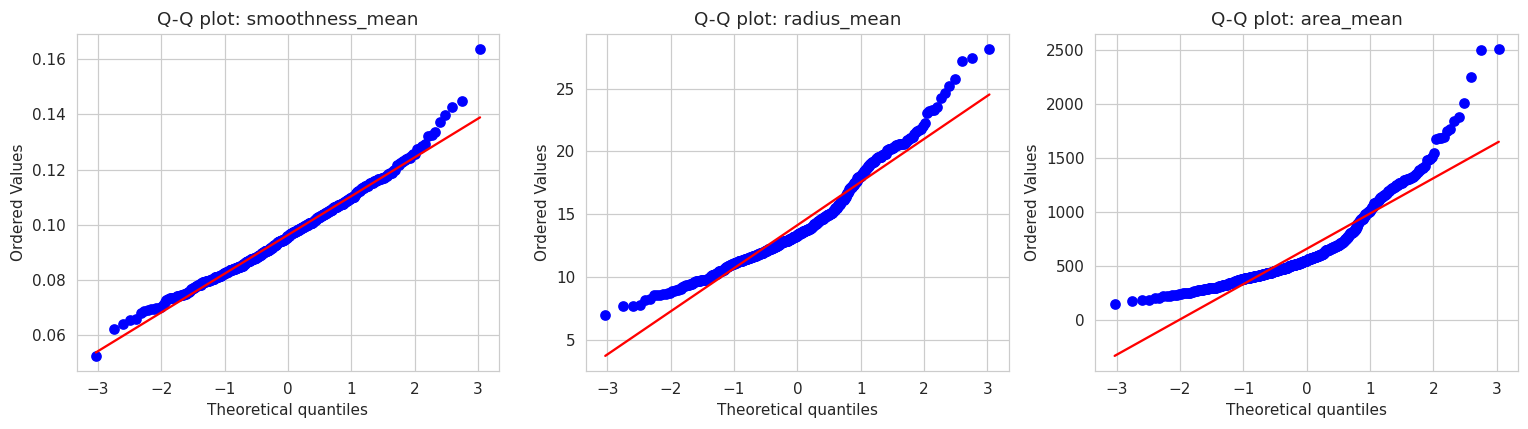

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["smoothness_mean", "radius_mean", "area_mean"]):
    stats.probplot(df[col], dist="norm", plot=ax)
    ax.set_title("Q-Q plot: " + col)
plt.tight_layout()
plt.show()

None of the ten features passes the Shapiro-Wilk test, all p-values are well below 0.05.
`smoothness_mean` is the closest to normal (W = 0.987), and its Q-Q plot follows the line apart
from the ends. `area_mean` is the furthest (W = 0.858), with the points bending away from the line
at the top. So tests that assume normality should be backed up by non-parametric ones, which is done
in the next section.

In [38]:
# 95% confidence interval of the mean radius for each class
for d in ["B", "M"]:
    r = df.loc[df["diagnosis"] == d, "radius_mean"]
    lo, hi = stats.t.interval(0.95, len(r) - 1, loc=r.mean(), scale=stats.sem(r))
    print("%s: mean %.2f, 95%% CI (%.2f, %.2f)" % (d, r.mean(), lo, hi))

B: mean 12.15, 95% CI (11.96, 12.33)
M: mean 17.46, 95% CI (17.03, 17.90)


The two intervals are far apart and do not overlap, so the difference in average radius between
benign (12.15) and malignant (17.46) is not down to chance.

## 11. 2D statistical analysis

Relationships between pairs of variables.

In [39]:
pairs_2d = [("radius_mean", "perimeter_mean"),
            ("radius_mean", "area_mean"),
            ("concavity_mean", "concave points_mean"),
            ("radius_mean", "texture_mean"),
            ("radius_mean", "fractal_dimension_mean")]
rows = []
for a, b in pairs_2d:
    rows.append([a, b, df[a].cov(df[b]),
                 stats.pearsonr(df[a], df[b])[0],
                 stats.spearmanr(df[a], df[b])[0],
                 stats.kendalltau(df[a], df[b])[0]])
pd.DataFrame(rows, columns=["x", "y", "covariance", "pearson", "spearman", "kendall"]).round(3)

,x,y,covariance,pearson,spearman,kendall
0,radius_mean,perimeter_mean,85.447,0.998,0.998,0.963
1,radius_mean,area_mean,1224.483,0.987,1.000,0.986
2,concavity_mean,concave points_mean,0.003,0.921,0.927,0.775
3,radius_mean,texture_mean,4.908,0.324,0.341,0.229
4,radius_mean,fractal_dimension_mean,-0.008,-0.312,-0.350,-0.246


Radius against perimeter and area are almost perfect in all three measures. For area, Spearman is
1.000 while Pearson is 0.987, because area grows with the square of the radius. The relationship is
perfectly monotonic but not a straight line.

Radius against texture is weak (0.32) and radius against fractal dimension is the only negative
pair (-0.31). Kendall's tau is lower than the other two for every pair except area, which is normal since it
is measured on a different scale.

In [40]:
# compare each feature between benign and malignant
b = df[df["diagnosis"] == "B"]
m = df[df["diagnosis"] == "M"]
tests = pd.DataFrame({
    "t stat": [stats.ttest_ind(m[c], b[c], equal_var=False)[0] for c in mean_cols],
    "t p-value": [stats.ttest_ind(m[c], b[c], equal_var=False)[1] for c in mean_cols],
    "Mann-Whitney p-value": [stats.mannwhitneyu(m[c], b[c])[1] for c in mean_cols],
}, index=mean_cols)
tests.sort_values("t stat", ascending=False)

,t stat,t p-value,Mann-Whitney p-value
concave points_mean,24.844810,3.127316e-71,1.006324e-76
perimeter_mean,22.935314,1.023141e-66,3.553870e-71
radius_mean,22.208798,1.684459e-64,2.692943e-68
concavity_mean,20.332425,3.742121e-58,2.164549e-68
area_mean,19.640990,3.284366e-52,1.539780e-68
compactness_mean,15.818246,9.607863e-42,8.951992e-48
texture_mean,11.022087,3.019055e-25,3.428627e-28
smoothness_mean,9.297355,5.573331e-19,7.793007e-19
symmetry_mean,8.112198,5.957651e-15,2.268050e-15
fractal_dimension_mean,-0.296866,7.667216e-01,5.371856e-01


Welch's t-test was used since the malignant group has a larger spread, and Mann-Whitney was added
because the features are not normal. Both tests agree.

Nine of the ten features differ significantly between benign and malignant, with `concave
points_mean` having the largest t statistic (24.8). The one exception is `fractal_dimension_mean`,
where the p-value is 0.77 (t-test) and 0.54 (Mann-Whitney), so there is no evidence it differs
between the two classes. This matches its near zero correlation with the diagnosis in Phase 1.

In [41]:
ct = pd.crosstab(df["radius_group"], df["diagnosis"])
chi2, p, dof, expected = stats.chi2_contingency(ct)
print("Chi-square: %.2f, dof: %d, p-value: %.2e" % (chi2, dof, p))
print()
print("Expected counts if radius and diagnosis were unrelated:")
print(pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(1))

Chi-square: 330.35, dof: 3, p-value: 2.69e-71

Expected counts if radius and diagnosis were unrelated:
diagnosis        B     M
radius_group            
Small         89.7  53.3
Medium        89.1  52.9
Large         89.1  52.9
Very large    89.1  52.9


If radius group and diagnosis were independent we would expect about 53 malignant cases in every
group. The actual counts range from 3 in the smallest group to 136 in the largest, and the
chi-square test gives p = 2.7e-71, so the two are strongly related.

area_mean = 98.60 * radius_mean + -738.04
R squared: 0.975


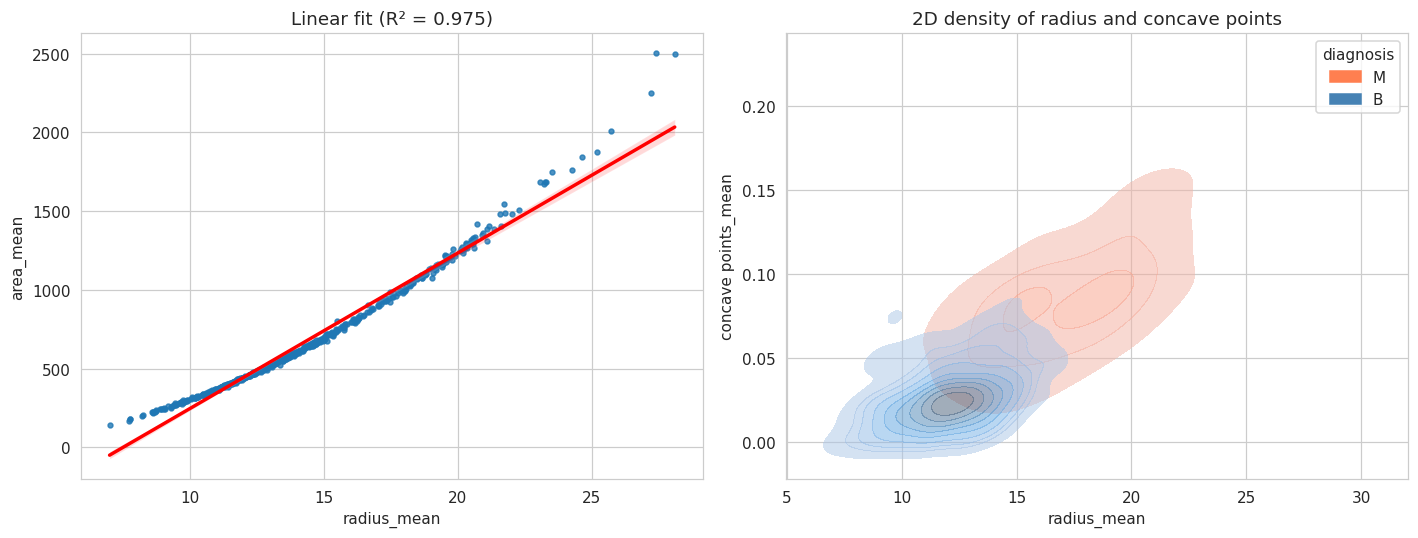

In [42]:
lin = stats.linregress(df["radius_mean"], df["area_mean"])
print("area_mean = %.2f * radius_mean + %.2f" % (lin.slope, lin.intercept))
print("R squared: %.3f" % lin.rvalue ** 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.regplot(data=df, x="radius_mean", y="area_mean", ax=axes[0],
            scatter_kws={"s": 10}, line_kws={"color": "red"})
axes[0].set_title("Linear fit (R² = %.3f)" % lin.rvalue ** 2)
sns.kdeplot(data=df, x="radius_mean", y="concave points_mean", hue="diagnosis",
            palette=colors, fill=True, alpha=0.5, ax=axes[1])
axes[1].set_title("2D density of radius and concave points")
plt.tight_layout()
plt.show()

A straight line explains 97.5% of the variation in area, but the plot shows the points curving
above the line at both ends and below it in the middle. This is because area depends on radius
squared, so a linear model is not the right shape even though R² is high.

The density plot shows the benign cases packed tightly around a radius of 12 and low concave
points, while the malignant cases are spread over a much wider region. The two only overlap between
a radius of about 13 and 16.

## 12. 3D statistical analysis

Looking at three variables together.

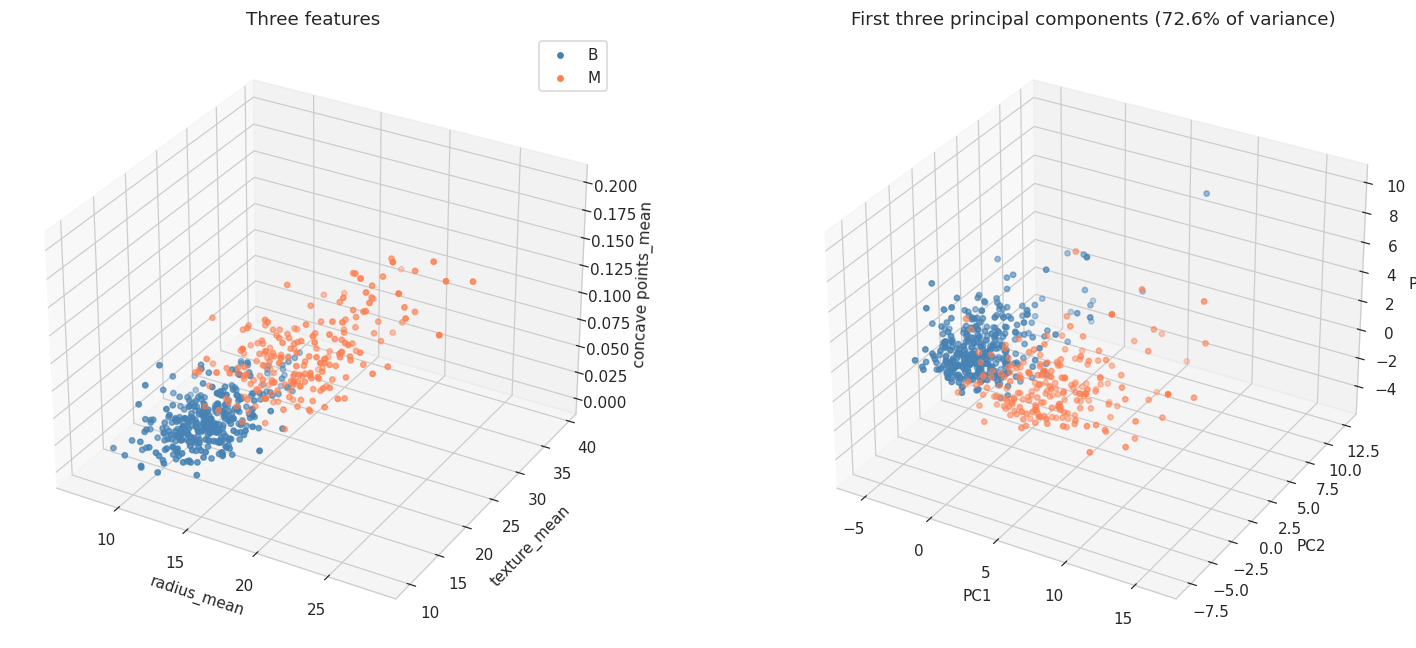

In [43]:
pca3 = PCA(n_components=3)
comp3 = pca3.fit_transform(df_scaled)

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
for d in ["B", "M"]:
    s = (df["diagnosis"] == d).values
    ax1.scatter(df.loc[s, "radius_mean"], df.loc[s, "texture_mean"],
                df.loc[s, "concave points_mean"], c=colors[d], label=d, s=12)
    ax2.scatter(comp3[s, 0], comp3[s, 1], comp3[s, 2], c=colors[d], label=d, s=12)
ax1.set_xlabel("radius_mean")
ax1.set_ylabel("texture_mean")
ax1.set_zlabel("concave points_mean")
ax1.set_title("Three features")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("PC3")
ax2.set_title("First three principal components (%.1f%% of variance)"
              % (pca3.explained_variance_ratio_.sum() * 100))
ax1.legend()
plt.tight_layout()
plt.show()

In the feature plot the malignant cases rise along both the radius and concave points axes, while
texture spreads both classes out without separating them much. The first three principal
components hold 72.6% of the variance, and the classes separate mainly along PC1, the extra two
components add little to the separation.

In [44]:
three = ["radius_mean", "texture_mean", "concave points_mean"]
print("Covariance matrix:")
print(df[three].cov().round(4))
print()
print("Correlation matrix:")
print(df[three].corr().round(3))

Covariance matrix:
                     radius_mean  texture_mean  concave points_mean
radius_mean              12.4189        4.9076               0.1125
texture_mean              4.9076       18.4989               0.0490
concave points_mean       0.1125        0.0490               0.0015

Correlation matrix:
                     radius_mean  texture_mean  concave points_mean
radius_mean                1.000         0.324                0.823
texture_mean               0.324         1.000                0.293
concave points_mean        0.823         0.293                1.000


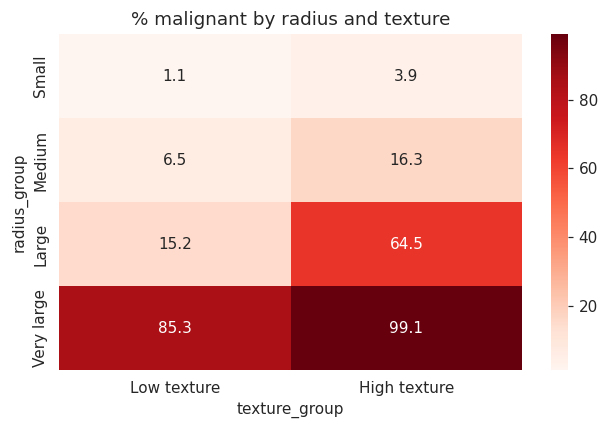

In [45]:
# % malignant for each combination of radius group and texture group
df["texture_group"] = pd.qcut(df["texture_mean"], 2, labels=["Low texture", "High texture"])
pivot = pd.pivot_table(df, values="target", index="radius_group",
                       columns="texture_group", aggfunc="mean", observed=False) * 100

plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds")
plt.title("% malignant by radius and texture")
plt.tight_layout()
plt.show()

Within every radius group, the high texture half has a higher malignant rate. The effect is biggest
for the large group, where the rate goes from 15.2% with low texture to 64.5% with high texture. So
texture does add information once size is known, even though it is only weakly related to radius.

In [46]:
# correlation with the diagnosis after removing the effect of radius
def partial_corr(x, y, z):
    rx = df[x] - np.polyval(np.polyfit(df[z], df[x], 1), df[z])
    ry = df[y] - np.polyval(np.polyfit(df[z], df[y], 1), df[z])
    return np.corrcoef(rx, ry)[0, 1]

for col in ["texture_mean", "concave points_mean", "smoothness_mean", "perimeter_mean"]:
    print("%-20s r = %.3f   partial r (radius fixed) = %.3f"
          % (col, df[col].corr(df["target"]), partial_corr(col, "target", "radius_mean")))

texture_mean         r = 0.415   partial r (radius fixed) = 0.277
concave points_mean  r = 0.777   partial r (radius fixed) = 0.453
smoothness_mean      r = 0.359   partial r (radius fixed) = 0.348
perimeter_mean       r = 0.743   partial r (radius fixed) = 0.317


In [47]:
# multiple regression: concave points from radius and texture
y = df["concave points_mean"]
A = np.column_stack([df["radius_mean"], df["texture_mean"], np.ones(len(df))])
coef = np.linalg.lstsq(A, y, rcond=None)[0]
r2 = 1 - ((y - A @ coef) ** 2).sum() / ((y - y.mean()) ** 2).sum()
print("concave points_mean = %.4f * radius + %.4f * texture + %.4f" % tuple(coef))
print("R squared: %.3f" % r2)

concave points_mean = 0.0089 * radius + 0.0003 * texture + -0.0828
R squared: 0.677


Once radius is held fixed, `perimeter_mean` drops from 0.743 to 0.317, since most of what it says
about the diagnosis is already in the radius. `concave points_mean` keeps the strongest link (0.453)
and `smoothness_mean` barely changes (0.359 to 0.348), so these carry information of their own.

The multiple regression shows that radius and texture together explain 67.7% of the variation in
concave points. Texture adds very little to it, its coefficient is close to zero.

## 13. K-means clustering

K-means is run on all 30 scaled features. The diagnosis is not given to the algorithm, it is only
used afterwards to check whether the clusters match it.

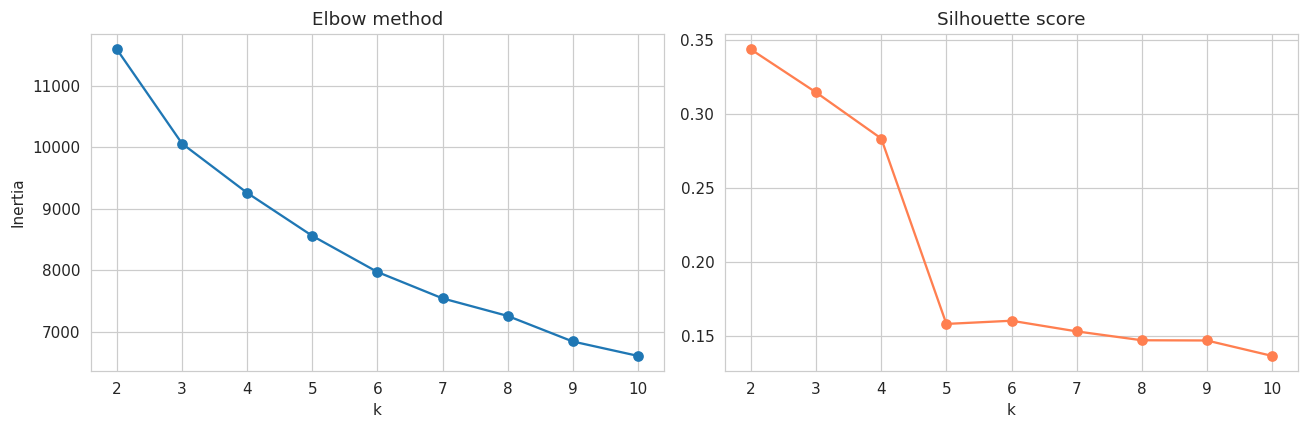

,inertia,silhouette
2,11595.527,0.343
3,10061.798,0.314
4,9258.989,0.283
5,8558.661,0.158
6,7970.264,0.160
7,7540.319,0.153
8,7254.326,0.147
9,6837.629,0.147
10,6603.404,0.137


In [48]:
X = df_scaled.values
ks = range(2, 11)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, inertia, marker="o")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[1].plot(ks, sil, marker="o", color="coral")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")
plt.tight_layout()
plt.show()

pd.DataFrame({"inertia": inertia, "silhouette": sil}, index=ks).round(3)

The inertia drops most sharply from 2 to 3 clusters and then flattens out, so there is no very
clear elbow. The silhouette score is highest at k = 2 (0.343) and falls as k increases, so 2
clusters is the best choice, which also matches the two diagnosis classes.

In [49]:
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
df["kmeans"] = kmeans.fit_predict(X)

print(pd.crosstab(df["kmeans"], df["diagnosis"]))
print()
print("Silhouette score: %.3f" % silhouette_score(X, df["kmeans"]))
print("Adjusted Rand index: %.3f" % adjusted_rand_score(df["diagnosis"], df["kmeans"]))

diagnosis    B    M
kmeans             
0          339   36
1           18  176

Silhouette score: 0.343
Adjusted Rand index: 0.654


In [50]:
# average of the mean features in each cluster
df.groupby("kmeans")[mean_cols].mean().T.round(3)

kmeans,0,1
radius_mean,12.427,17.415
texture_mean,18.262,21.275
perimeter_mean,79.820,115.453
area_mean,486.772,979.857
smoothness_mean,0.092,0.105
compactness_mean,0.077,0.158
concavity_mean,0.043,0.178
concave points_mean,0.026,0.093
symmetry_mean,0.173,0.198
fractal_dimension_mean,0.062,0.065


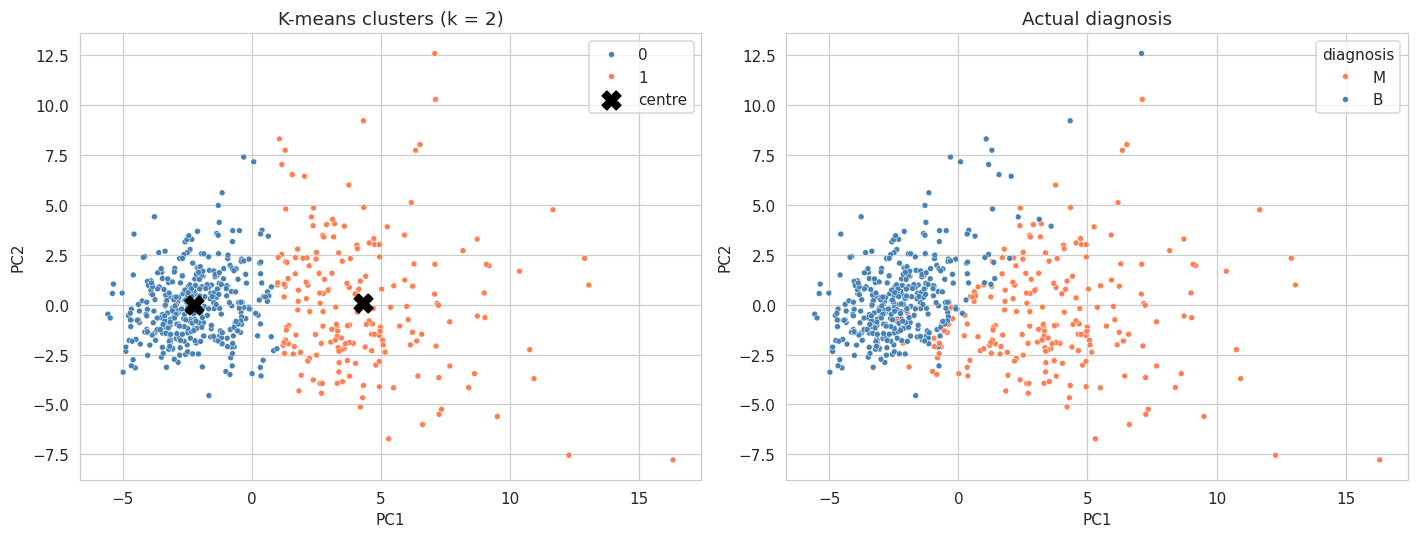

In [51]:
centers = pca.transform(kmeans.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=pca_df["PC1"], y=pca_df["PC2"], hue=df["kmeans"],
                palette=["steelblue", "coral"], s=15, ax=axes[0])
axes[0].scatter(centers[:, 0], centers[:, 1], c="black", marker="X", s=150, label="centre")
axes[0].set_title("K-means clusters (k = 2)")
axes[0].legend()
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="diagnosis", palette=colors, s=15, ax=axes[1])
axes[1].set_title("Actual diagnosis")
plt.tight_layout()
plt.show()

Cluster 0 is mostly benign (339 B, 36 M) and cluster 1 is mostly malignant (176 M, 18 B). If each
cluster is labelled by its majority class, 515 of the 569 cases (90.5%) are placed correctly, even
though the algorithm never saw the diagnosis. The adjusted Rand index is 0.654, where 0 would mean
random and 1 a perfect match.

The cluster averages look like the class averages from Phase 1, with cluster 1 having a much larger
radius and area and around four times the concavity. Most of the mistakes are malignant cases
placed in cluster 0, and on the PCA plot these are the ones sitting near the border around PC1 = 0.

## 14. Hierarchical clustering

Agglomerative clustering starts with every row as its own cluster and keeps merging the two
closest ones. The dendrogram shows the order of the merges.

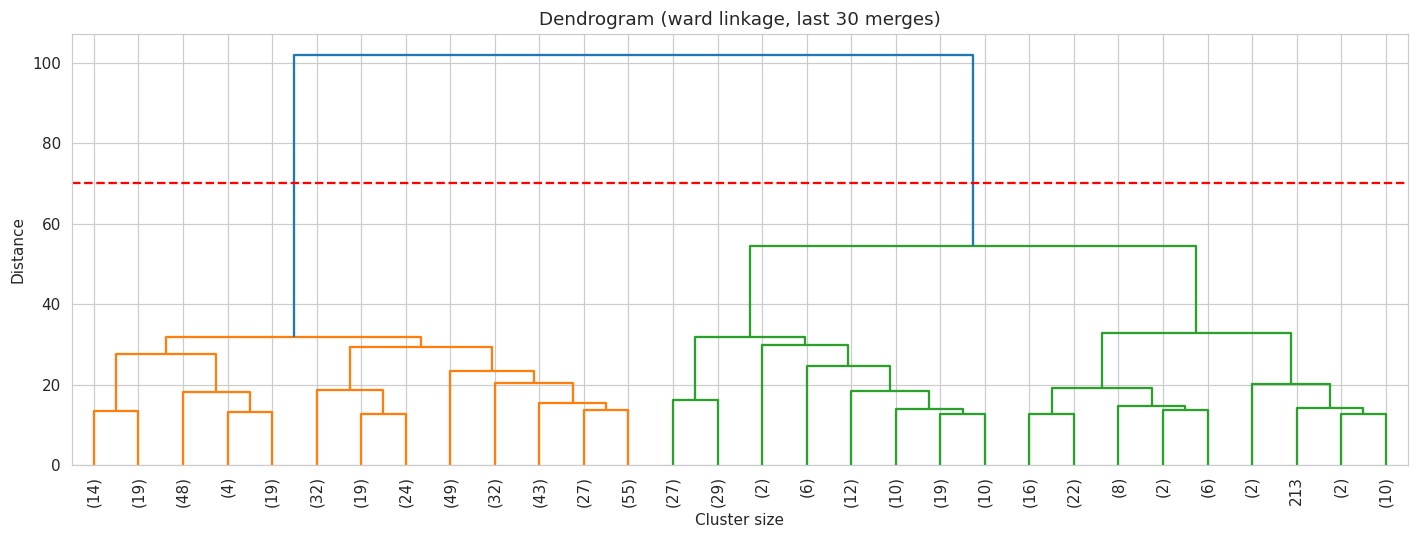

Last five merge distances: [ 31.7  31.9  32.7  54.4 102. ]


In [52]:
Z = linkage(X, method="ward")

plt.figure(figsize=(13, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90)
plt.axhline(70, color="red", linestyle="--")
plt.title("Dendrogram (ward linkage, last 30 merges)")
plt.xlabel("Cluster size")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

print("Last five merge distances:", Z[-5:, 2].round(1))

The last merge happens at a distance of 102, far above the one before it (54.4). Cutting the tree
at 70, shown by the red line, gives two clusters, which agrees with the choice of k = 2 from
K-means.

In [53]:
# compare the different linkage methods with 2 clusters
rows = []
for method in ["ward", "complete", "average", "single"]:
    labels = AgglomerativeClustering(n_clusters=2, linkage=method).fit_predict(X)
    rows.append([method, silhouette_score(X, labels),
                 adjusted_rand_score(df["diagnosis"], labels), np.bincount(labels).tolist()])
pd.DataFrame(rows, columns=["linkage", "silhouette", "ARI", "cluster sizes"]).round(3)

,linkage,silhouette,ARI,cluster sizes
0,ward,0.339,0.575,"[184, 385]"
1,complete,0.661,0.005,"[567, 2]"
2,average,0.634,0.007,"[566, 3]"
3,single,0.661,0.005,"[567, 2]"


Complete, average and single linkage have much higher silhouette scores but they are misleading.
They split off only 2 or 3 extreme rows and put everything else in one cluster, so their ARI is
close to 0. Ward linkage is the only one that gives two balanced groups, so it is used below.

In [54]:
hier = AgglomerativeClustering(n_clusters=2, linkage="ward").fit_predict(X)
# make cluster 1 the mostly malignant one, same as K-means
df["hier"] = hier if df.loc[hier == 1, "target"].mean() > 0.5 else 1 - hier

print(pd.crosstab(df["hier"], df["diagnosis"]))
print()
print("Silhouette score: %.3f" % silhouette_score(X, df["hier"]))
print("Adjusted Rand index: %.3f" % adjusted_rand_score(df["diagnosis"], df["hier"]))
print("Agreement with K-means (ARI): %.3f" % adjusted_rand_score(df["kmeans"], df["hier"]))

diagnosis    B    M
hier               
0          337   48
1           20  164

Silhouette score: 0.339
Adjusted Rand index: 0.575
Agreement with K-means (ARI): 0.810


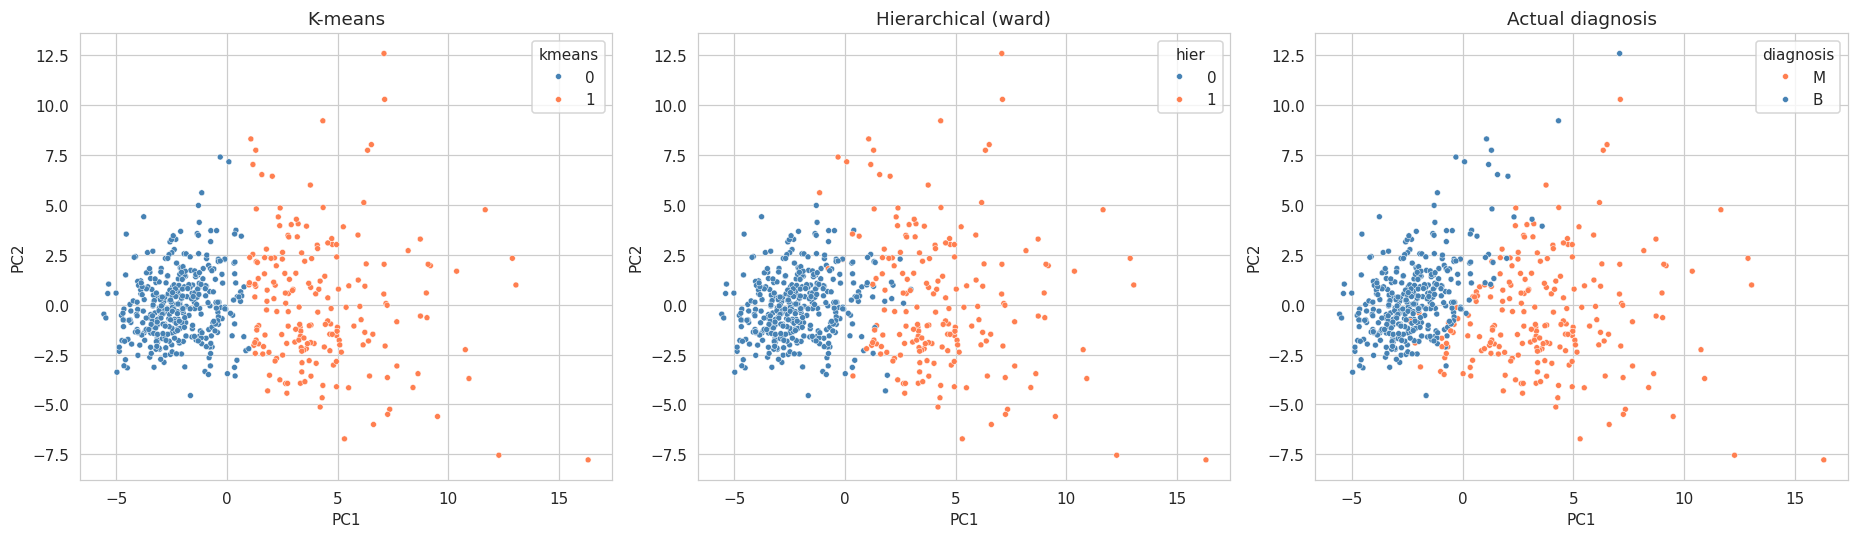

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col, title in zip(axes, ["kmeans", "hier", "diagnosis"],
                          ["K-means", "Hierarchical (ward)", "Actual diagnosis"]):
    sns.scatterplot(x=pca_df["PC1"], y=pca_df["PC2"], hue=df[col], s=15, ax=ax,
                    palette=colors if col == "diagnosis" else ["steelblue", "coral"])
    ax.set_title(title)
plt.tight_layout()
plt.show()

Ward clustering puts 501 of the 569 cases (88.0%) in the cluster matching their diagnosis, with an
ARI of 0.575. This is a little lower than K-means, mostly because 48 malignant cases end up in the
benign cluster compared to 36 for K-means. The two methods agree with each other closely (ARI 0.81)
and the three plots look almost the same, with the differences only along the border between the
two groups.

## 15. Phase 2 conclusion

**1D analysis.** All ten mean features are right skewed and none of them is normally distributed
according to the Shapiro-Wilk test. The concavity features vary the most relative to their mean and
fractal dimension and smoothness the least. The 95% confidence intervals for the mean radius of the
two classes do not overlap.

**2D analysis.** Nine of the ten mean features differ significantly between benign and malignant,
by both the t-test and the Mann-Whitney test. Fractal dimension is the only one that does not. The
chi-square test confirms that radius group and diagnosis are strongly related. Radius, perimeter and
area are almost perfectly related, and the area against radius relationship is curved rather than
linear.

**3D analysis.** Texture adds information once size is known, since the malignant rate is higher
for high texture in every radius group. Partial correlations show that `concave points_mean` and
`smoothness_mean` are related to the diagnosis independently of size, while most of what perimeter
tells us is already in the radius.

**Clustering.** Both methods found two natural groups in the data without being given the
diagnosis. K-means matched the diagnosis for 90.5% of the cases (ARI 0.654) and ward hierarchical
clustering for 88.0% (ARI 0.575). Other linkage methods failed because they separated only a few
outliers. The cases both methods get wrong are mostly malignant tumours on the small side,
which sit in the overlap region seen throughout the analysis.